# 🏎️ Analyse des pilotes ayant remporté au moins 30 Grands Prix de Formule 1
Projet de traitement de données — ENSAI 1A  
Les traitements sont désormais encapsulés dans des fonctions pour plus de clarté et de réutilisabilité.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import import_data as i_d

## 🎯 Objectif

Identifier les pilotes ayant remporté **au moins 30 victoires** en Grand Prix de Formule 1.
Nous présenterons un tableau, un graphique et des statistiques descriptives.

## 📥 Chargement des données

In [2]:
# Chargement des données
i_d.charger_donnees_depuis_bureau()

Dossier trouvé : /Users/jules/Desktop/donnees_formule_un
Fichiers CSV trouvés : [PosixPath('/Users/jules/Desktop/donnees_formule_un/circuits.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/status.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/lap_times.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/sprint_results.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/drivers.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/races.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/constructors.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/constructor_standings.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/qualifying.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/driver_standings.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/constructor_results.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/pit_stops.csv'), PosixPath('/Users/jules/Desktop/donnees_formule_un/seasons.csv'), PosixPath

## 🔎 Filtrage des vainqueurs

In [3]:
def filtrer_vainqueurs(results: pd.DataFrame) -> pd.DataFrame:
    '''
    Garde uniquement les résultats des pilotes ayant terminé premiers.

    Parameters
    ----------
    results : pd.DataFrame
        Table des résultats des courses.

    Returns
    -------
    pd.DataFrame
        Résultats filtrés pour les vainqueurs.
    '''
    return results[results['positionOrder'] == 1]

## 📈 Calcul du nombre de victoires par pilote

In [4]:
def compter_victoires(winners: pd.DataFrame, drivers: pd.DataFrame, seuil: int = 30) -> pd.DataFrame:
    '''
    Compte le nombre de victoires par pilote et filtre ceux avec au moins un seuil donné.

    Parameters
    ----------
    winners : pd.DataFrame
        Résultats filtrés pour les vainqueurs.
    drivers : pd.DataFrame
        Données des pilotes.
    seuil : int, optional
        Seuil minimal de victoires (default = 30).

    Returns
    -------
    pd.DataFrame
        Table des pilotes avec leur nombre de victoires.
    '''
    victory_counts = winners['driverId'].value_counts()
    victory_counts = victory_counts[victory_counts >= seuil]
    top_winners = pd.DataFrame({
        'driverId': victory_counts.index,
        'wins': victory_counts.values
    })
    top_winners = top_winners.merge(drivers, on='driverId')
    return top_winners

## 📊 Visualisation du nombre de victoires

In [5]:
def plot_victoires(top_winners: pd.DataFrame) -> None:
    '''
    Affiche un graphique du nombre de victoires des pilotes sélectionnés.

    Parameters
    ----------
    top_winners : pd.DataFrame
        Table des pilotes avec leur nombre de victoires.

    Returns
    -------
    None
    '''
    plt.figure(figsize=(12, 7))
    sns.set(style="whitegrid")
    sorted_data = top_winners.sort_values("wins", ascending=False)
    sns.barplot(x="wins", y="surname", data=sorted_data, palette="viridis")
    plt.title("Pilotes ayant remporté au moins 30 Grands Prix", fontsize=16)
    plt.xlabel("Nombre de victoires")
    plt.ylabel("Pilote")
    plt.show()

## 📊 Statistiques descriptives

In [6]:
def stats_victoires(top_winners: pd.DataFrame) -> None:
    '''
    Affiche les statistiques descriptives sur les victoires.

    Parameters
    ----------
    top_winners : pd.DataFrame
        Table des pilotes avec leur nombre de victoires.

    Returns
    -------
    None
    '''
    print(top_winners['wins'].describe())
    print("\nMédiane :", top_winners['wins'].median())
    print("Écart-type :", top_winners['wins'].std())

## ⚙️ Application concrète du traitement

,driverId,wins,driverRef,number,code,forename,surname,dob,nationality,url
0,1,104,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,30,91,michael_schumacher,\N,MSC,Michael,Schumacher,1969-01-03,German,http://en.wikipedia.org/wiki/Michael_Schumacher
2,830,61,max_verstappen,33,VER,Max,Verstappen,1997-09-30,Dutch,http://en.wikipedia.org/wiki/Max_Verstappen
3,20,53,vettel,5,VET,Sebastian,Vettel,1987-07-03,German,http://en.wikipedia.org/wiki/Sebastian_Vettel
4,117,51,prost,\N,\N,Alain,Prost,1955-02-24,French,http://en.wikipedia.org/wiki/Alain_Prost
5,102,41,senna,\N,\N,Ayrton,Senna,1960-03-21,Brazilian,http://en.wikipedia.org/wiki/Ayrton_Senna
6,4,32,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
7,95,31,mansell,\N,\N,Nigel,Mansell,1953-08-08,British,http://en.wikipedia.org/wiki/Nigel_Mansell


/var/folders/kc/4jjhfwsx60v74w2j7x_3dwkc0000gn/T/ipykernel_20516/2183620803.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="wins", y="surname", data=sorted_data, palette="viridis")


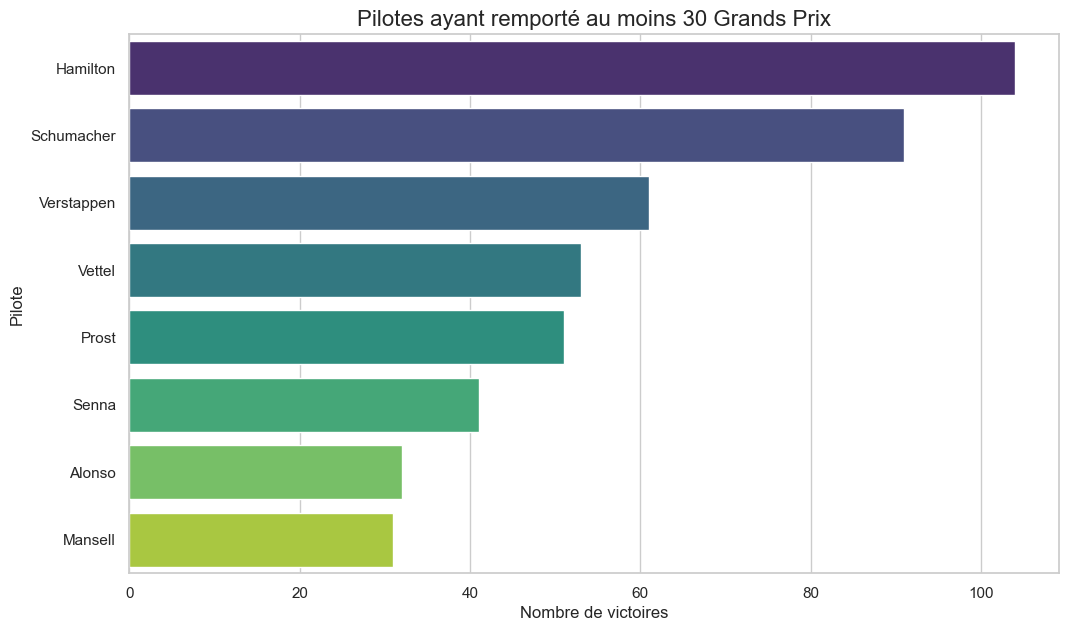

count      8.000000
mean      58.000000
std       26.677974
min       31.000000
25%       38.750000
50%       52.000000
75%       68.500000
max      104.000000
Name: wins, dtype: float64

Médiane : 52.0
Écart-type : 26.67797379326784


In [7]:
# Application
winners = filtrer_vainqueurs(results)
top_winners = compter_victoires(winners, drivers)
display(top_winners)
plot_victoires(top_winners)
stats_victoires(top_winners)